In [2]:
import pandas as pd
df = pd.read_csv("Indian_Kids_Screen_Time_.csv")

df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [3]:
df['Health_Impacts'].value_counts()

Health_Impacts
Poor Sleep                                       2268
Poor Sleep, Eye Strain                            979
Eye Strain                                        644
Poor Sleep, Anxiety                               608
Poor Sleep, Obesity Risk                          452
Anxiety                                           385
Poor Sleep, Eye Strain, Anxiety                   258
Obesity Risk                                      252
Poor Sleep, Eye Strain, Obesity Risk              188
Eye Strain, Anxiety                               135
Eye Strain, Obesity Risk                          106
Poor Sleep, Anxiety, Obesity Risk                  78
Anxiety, Obesity Risk                              69
Poor Sleep, Eye Strain, Anxiety, Obesity Risk      37
Eye Strain, Anxiety, Obesity Risk                  35
Name: count, dtype: int64

In [4]:
df['Health_Impacts'].unique()

array(['Poor Sleep, Eye Strain', 'Poor Sleep', nan, 'Poor Sleep, Anxiety',
       'Poor Sleep, Obesity Risk', 'Eye Strain', 'Obesity Risk',
       'Anxiety', 'Poor Sleep, Anxiety, Obesity Risk',
       'Eye Strain, Obesity Risk', 'Eye Strain, Anxiety, Obesity Risk',
       'Anxiety, Obesity Risk', 'Poor Sleep, Eye Strain, Obesity Risk',
       'Poor Sleep, Eye Strain, Anxiety',
       'Poor Sleep, Eye Strain, Anxiety, Obesity Risk',
       'Eye Strain, Anxiety'], dtype=object)

In [5]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [6]:
df['Gender'].value_counts()

Gender
Male      4942
Female    4770
Name: count, dtype: int64

In [7]:
df['Primary_Device'].unique()

array(['Smartphone', 'Laptop', 'TV', 'Tablet'], dtype=object)

In [8]:
df['Primary_Device'].value_counts()

Primary_Device
Smartphone    4568
TV            2487
Laptop        1433
Tablet        1224
Name: count, dtype: int64

In [9]:
df['Exceeded_Recommended_Limit'].unique()

array([ True, False])

In [10]:
df["Age_Band"] = pd.cut(
    df["Age"],
    bins=[4, 8, 11, 14, 18],
    labels=["Early Childhood", "Pre-Teen", "Early Teen", "Late Teen"]
)

In [11]:
df[['Age','Age_Band']].head()

,Age,Age_Band
0,14,Early Teen
1,11,Pre-Teen
2,18,Late Teen
3,15,Late Teen
4,12,Early Teen


In [12]:
df['Age_Band'].value_counts()

Age_Band
Late Teen          3499
Early Teen         2673
Pre-Teen           2628
Early Childhood     912
Name: count, dtype: int64

In [13]:
df['Primary_Device'].value_counts()

Primary_Device
Smartphone    4568
TV            2487
Laptop        1433
Tablet        1224
Name: count, dtype: int64

In [14]:
# create activity_type column
df['activity_type'] = ''

# assign values based on ratio
df.loc[df['Educational_to_Recreational_Ratio'] > 1, 'activity_type'] = 'Educational Usage'
df.loc[df['Educational_to_Recreational_Ratio'] < 1, 'activity_type'] = 'Recreational Usage'
df.loc[df['Educational_to_Recreational_Ratio'] == 1, 'activity_type'] = 'Balanced Usage'

# count of each activity type
counts = df['activity_type'].value_counts()
print(counts)

# total records
total = len(df)
print("Total Records:", total)

# percentage share of each activity type
activity_share = (counts / total) * 100
print(activity_share)

activity_type
Recreational Usage    9712
Name: count, dtype: int64
Total Records: 9712
activity_type
Recreational Usage    100.0
Name: count, dtype: float64


In [15]:
#health_issue_present - Derived field
df['health_issue_present'] = df['Health_Impacts'].apply(
    lambda x: 'no health issue' if x == 'None' else 'Health Issue'
)
df.loc[df['Health_Impacts']=='No Health Impact','health_issue_present']='No Health Issue'
print(df['health_issue_present'].value_counts())

health_issue_present
Health Issue    9712
Name: count, dtype: int64


In [16]:
#device type - Derived field
df['device_type']=''
df.loc[df['Primary_Device']=='Smartphone','device_type']='portable'
df.loc[df['Primary_Device']=='Laptop','device_type']='portable'
df.loc[df['Primary_Device']=='Tablet','device_type']='portable'
df.loc[df['Primary_Device']=='TV','device_type']='wall-mounted'
df[['Primary_Device','device_type']].head()

,Primary_Device,device_type
0,Smartphone,portable
1,Laptop,portable
2,TV,wall-mounted
3,Laptop,portable
4,Smartphone,portable


In [18]:
#Duration - Derived field
# create duration category
df['Duration_Category'] = ''

df.loc[df['Avg_Daily_Screen_Time_hr'] < 2, 'Duration_Category'] = 'Low (0-2 hrs)'
df.loc[(df['Avg_Daily_Screen_Time_hr'] >= 2) & 
       (df['Avg_Daily_Screen_Time_hr'] < 4), 'Duration_Category'] = 'Moderate (2-4 hrs)'
df.loc[(df['Avg_Daily_Screen_Time_hr'] >= 4) & 
       (df['Avg_Daily_Screen_Time_hr'] < 6), 'Duration_Category'] = 'High (4-6 hrs)'
df.loc[df['Avg_Daily_Screen_Time_hr'] >= 6, 'Duration_Category'] = 'Very High (6+ hrs)'

print(df['Duration_Category'].value_counts())

Duration_Category
High (4-6 hrs)        4606
Moderate (2-4 hrs)    2914
Very High (6+ hrs)    1366
Low (0-2 hrs)          826
Name: count, dtype: int64


In [19]:
df['High_Education_Use'] = df['Educational_to_Recreational_Ratio'] > 1

In [20]:
print("\nHigh Education Usage Flag:")
print(df[['Educational_to_Recreational_Ratio', 'High_Education_Use']].head())

print("\nHigh Education Use Count:")
print(df['High_Education_Use'].value_counts())


High Education Usage Flag:
   Educational_to_Recreational_Ratio  High_Education_Use
0                               0.42               False
1                               0.30               False
2                               0.32               False
3                               0.39               False
4                               0.49               False

High Education Use Count:
High_Education_Use
False    9712
Name: count, dtype: int64


In [21]:
print("\nHigher Education Usage Flag:")
print(df[['Educational_to_Recreational_Ratio', 'High_Education_Use']].head())
print("\nHigh Education Use Count:")
print(df['High_Education_Use'].value_counts())


Higher Education Usage Flag:
   Educational_to_Recreational_Ratio  High_Education_Use
0                               0.42               False
1                               0.30               False
2                               0.32               False
3                               0.39               False
4                               0.49               False

High Education Use Count:
High_Education_Use
False    9712
Name: count, dtype: int64


In [22]:
df['Exceeded_Flag'] = df['Exceeded_Recommended_Limit']

In [23]:
print("\nExceeded Limit Flag:")
print(df[['Exceeded_Recommended_Limit', 'Exceeded_Flag']].head())
print("\nExceeded Flag Count:")
print(df['Exceeded_Flag'].value_counts())


Exceeded Limit Flag:
   Exceeded_Recommended_Limit  Exceeded_Flag
0                        True           True
1                        True           True
2                        True           True
3                       False          False
4                        True           True

Exceeded Flag Count:
Exceeded_Flag
True     8301
False    1411
Name: count, dtype: int64


In [29]:
#Weekday - Derived Field
# calculate mean screen time
mean_screen_time = df['Avg_Daily_Screen_Time_hr'].mean()

# create weekday_flag column
df['weekday_flag'] = ''

# assign labels based on mean comparison
df.loc[df['Avg_Daily_Screen_Time_hr'] > mean_screen_time, 'weekday_flag'] = 'weekend'
df.loc[df['Avg_Daily_Screen_Time_hr'] <= mean_screen_time, 'weekday_flag'] = 'weekday'

# print counts
print(df['weekday_flag'].value_counts())

# preview
print(df[['Avg_Daily_Screen_Time_hr', 'weekday_flag']].head())

weekday_flag
weekend    5048
weekday    4664
Name: count, dtype: int64
   Avg_Daily_Screen_Time_hr weekday_flag
0                      3.99      weekday
1                      4.61      weekend
2                      3.73      weekday
3                      1.21      weekday
4                      5.89      weekend


In [31]:
# Device Category
portable_devices = ["Mobile", "Tablet", "Laptop"]
wall_devices = ["Desktop", "TV"]
df["Device_Type"] = df["Primary_Device"].apply(
    lambda x: "Portable" if x in portable_devices
    else "Wall_Mounted" if x in wall_devices
    else "Other"
)
print(df["Device_Type"].value_counts())

Device_Type
Other           4568
Portable        2657
Wall_Mounted    2487
Name: count, dtype: int64


In [35]:
df["Device_Preference"] = df["Device_Type"].apply(
    lambda x: "Portable_User" if x == "Portable"
    else "Wall_Device_User" if x == "Wall_Mounted"
    else "Other_User"
)
print(df["Device_Preference"].value_counts())

Device_Preference
Other_User          4568
Portable_User       2657
Wall_Device_User    2487
Name: count, dtype: int64


In [36]:
mean_time = df["Avg_Daily_Screen_Time_hr"].mean()
df["Usage_Day_Type"] = df["Avg_Daily_Screen_Time_hr"].apply(
    lambda x: "Above_Mean" if x > mean_time else "Below_Mean"
)
print(df["Usage_Day_Type"].value_counts())


Usage_Day_Type
Above_Mean    5048
Below_Mean    4664
Name: count, dtype: int64


In [37]:
df["Usage_Focus"] = df["Educational_to_Recreational_Ratio"].apply(
    lambda x: "Education_Dominant" if x > 1
    else "Recreational_Dominant" if x < 1
    else "Both"
)
print(df["Usage_Focus"].value_counts())

Usage_Focus
Recreational_Dominant    9712
Name: count, dtype: int64


In [38]:
df["Health_Impact_Category"] = df["Health_Impacts"].str.strip().str.title()
print(df["Health_Impact_Category"].value_counts())

Health_Impact_Category
Poor Sleep                                       2268
Poor Sleep, Eye Strain                            979
Eye Strain                                        644
Poor Sleep, Anxiety                               608
Poor Sleep, Obesity Risk                          452
Anxiety                                           385
Poor Sleep, Eye Strain, Anxiety                   258
Obesity Risk                                      252
Poor Sleep, Eye Strain, Obesity Risk              188
Eye Strain, Anxiety                               135
Eye Strain, Obesity Risk                          106
Poor Sleep, Anxiety, Obesity Risk                  78
Anxiety, Obesity Risk                              69
Poor Sleep, Eye Strain, Anxiety, Obesity Risk      37
Eye Strain, Anxiety, Obesity Risk                  35
Name: count, dtype: int64


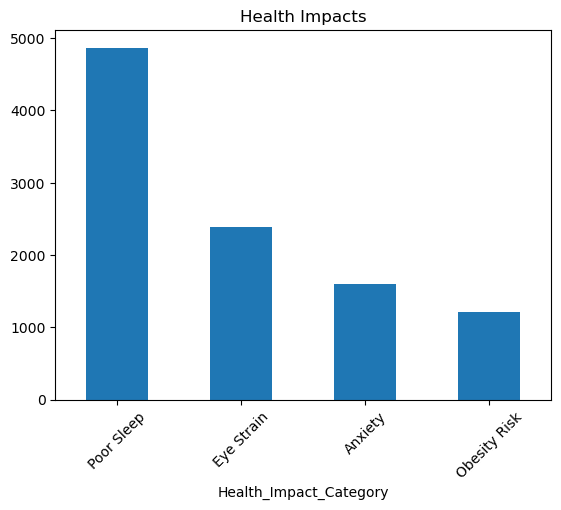

In [39]:
df["Health_Impact_Category"] = df["Health_Impact_Category"].str.split(",")
df_exploded = df.explode("Health_Impact_Category")
df_exploded["Health_Impact_Category"] = df_exploded["Health_Impact_Category"].str.strip()
df_exploded["Health_Impact_Category"].value_counts().plot(kind="bar")
plt.xticks(rotation=45)
plt.title("Health Impacts")
plt.show()

Univariate and Bivariate Analysis

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

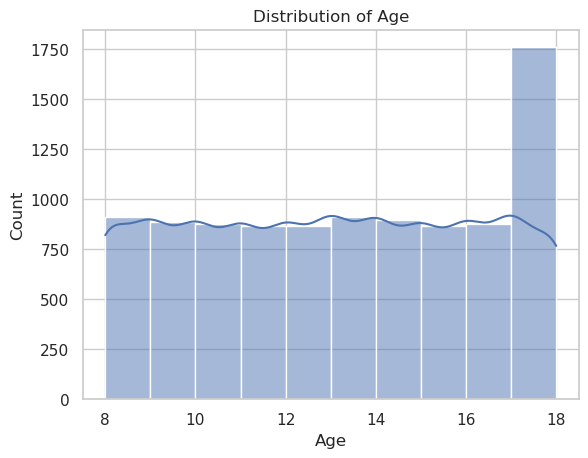

In [52]:
#Histogram 
plt.figure()
sns.histplot(df['Age'], bins=10, kde=True)
plt.title('Distribution of Age')
plt.show()

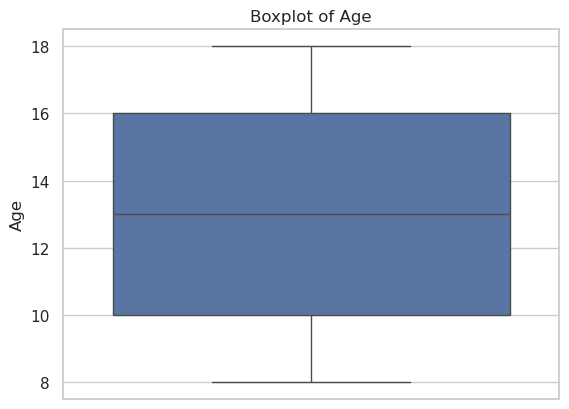

In [53]:
#Boxplot
plt.figure()
sns.boxplot(y=df['Age'])
plt.title('Boxplot of Age')
plt.show()

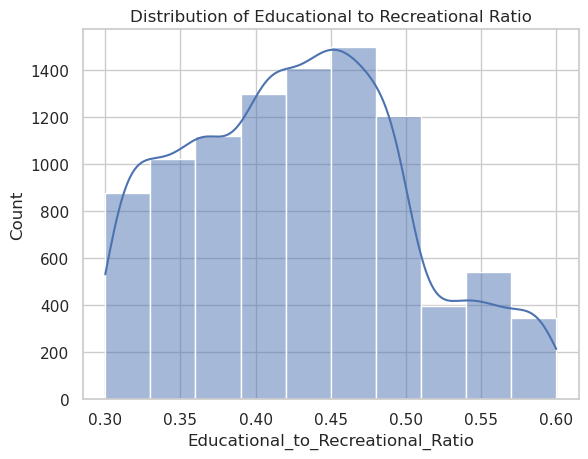

In [54]:
#Educational_to_Recreational_Ratio (Numeric)
plt.figure()
sns.histplot(df['Educational_to_Recreational_Ratio'], bins=10, kde=True)
plt.title('Distribution of Educational to Recreational Ratio')
plt.show()

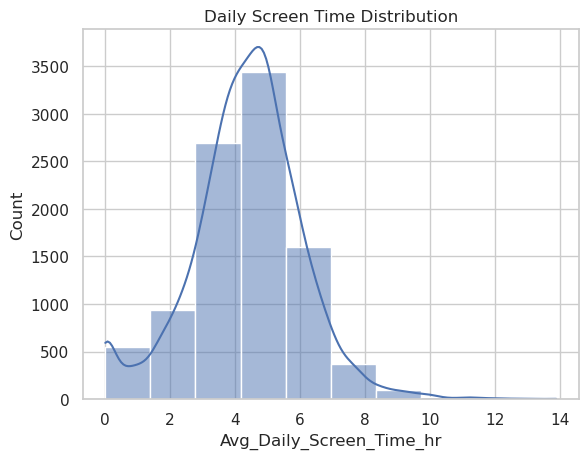

In [55]:
plt.figure()
sns.histplot(df['Avg_Daily_Screen_Time_hr'], bins=10, kde=True)
plt.title('Daily Screen Time Distribution')
plt.show()

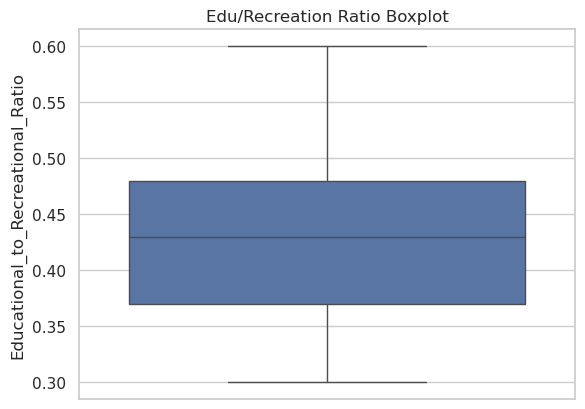

In [56]:
plt.figure()
sns.boxplot(y=df['Educational_to_Recreational_Ratio'])
plt.title('Edu/Recreation Ratio Boxplot')
plt.show()

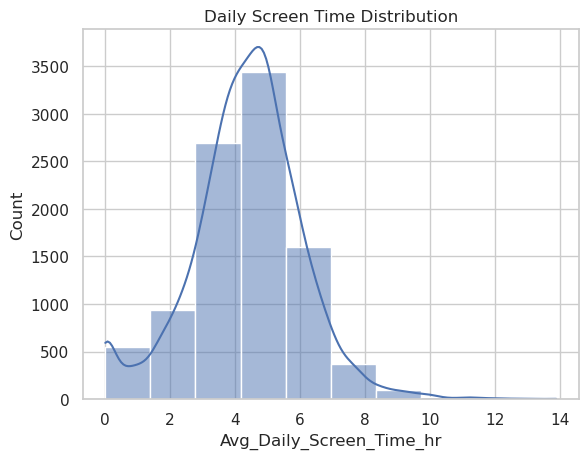

In [57]:
#Screen TIme
plt.figure()
sns.histplot(df['Avg_Daily_Screen_Time_hr'], bins=10, kde=True)
plt.title('Daily Screen Time Distribution')
plt.show()


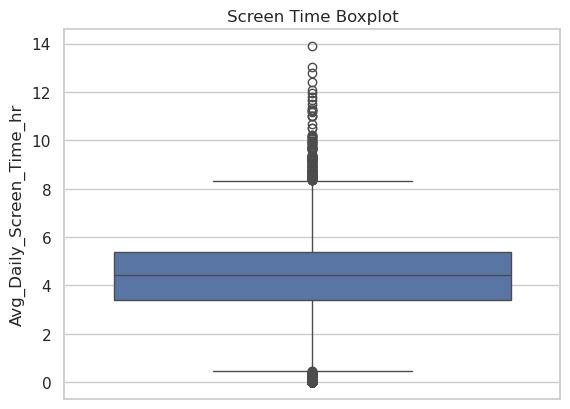

In [58]:
plt.figure()
sns.boxplot(y=df['Avg_Daily_Screen_Time_hr'])
plt.title('Screen Time Boxplot')
plt.show()

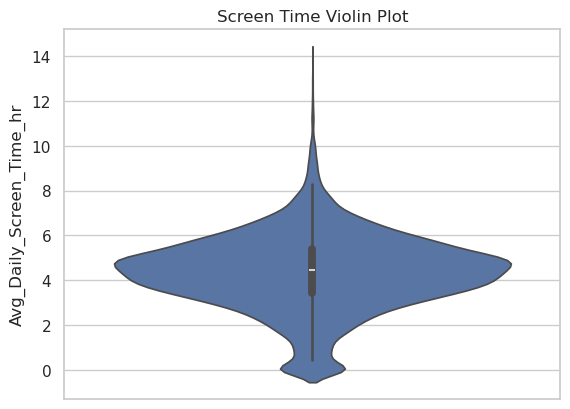

In [59]:
plt.figure()
sns.violinplot(y=df['Avg_Daily_Screen_Time_hr'])
plt.title('Screen Time Violin Plot')
plt.show()

CATEGORICAL VARIABLES

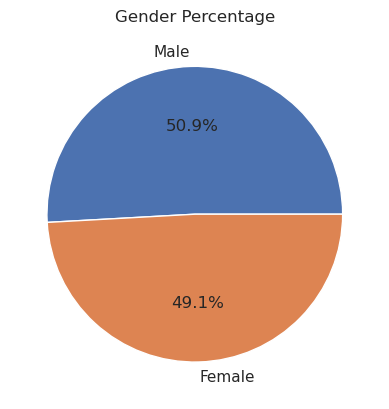

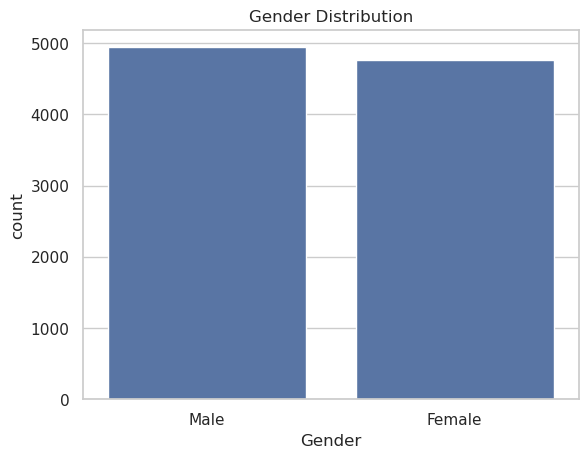

In [62]:
#Gender
plt.figure()
df['Gender'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Gender Percentage')
plt.ylabel('')
plt.show()

plt.figure()
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.show()

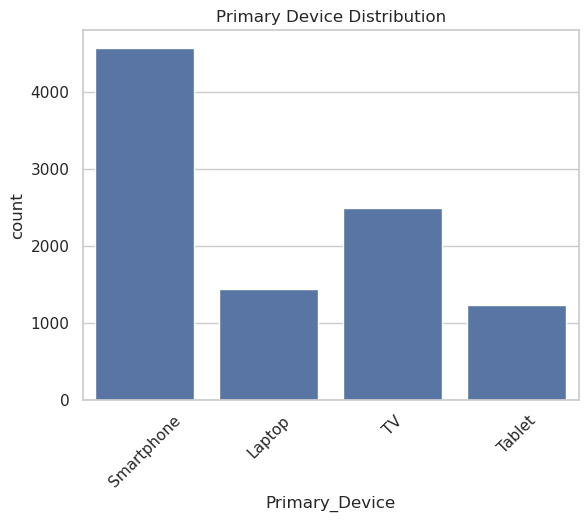

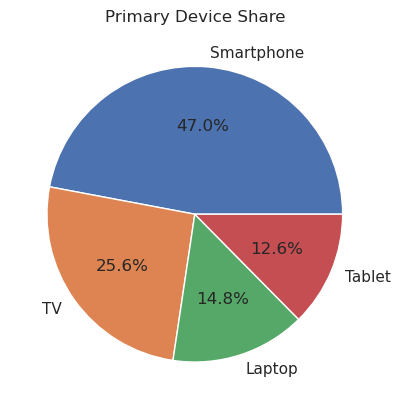

In [63]:
#Primary Device
plt.figure()
sns.countplot(x='Primary_Device', data=df)
plt.title('Primary Device Distribution')
plt.xticks(rotation=45)
plt.show()

plt.figure()
df['Primary_Device'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Primary Device Share')
plt.ylabel('')
plt.show()

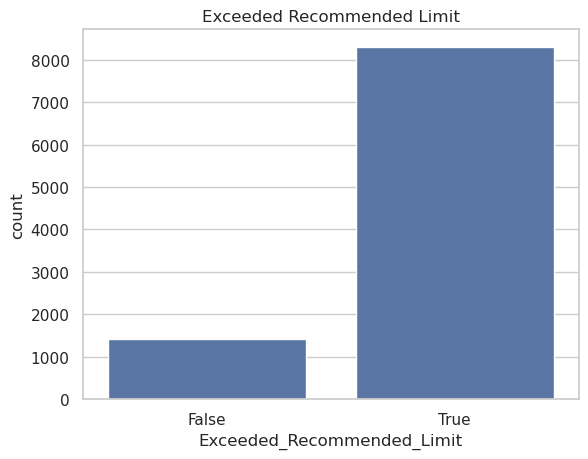

In [64]:
#Exceeded Recommended Limit
plt.figure()
sns.countplot(x='Exceeded_Recommended_Limit', data=df)
plt.title('Exceeded Recommended Limit')
plt.show()

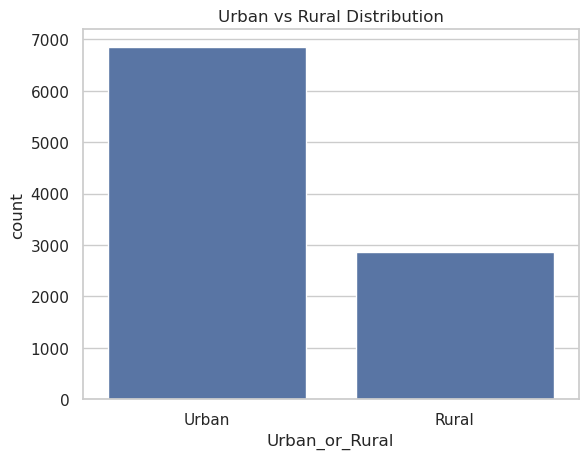

In [65]:
#Urban_Rural
plt.figure()
sns.countplot(x='Urban_or_Rural', data=df)
plt.title('Urban vs Rural Distribution')
plt.show()

Bivariate Analysis
1. Numeric Vs Numeric
2. Categorical Vs Numeric
3. Categorical Vs Categorical

NUMERIC vs NUMERIC

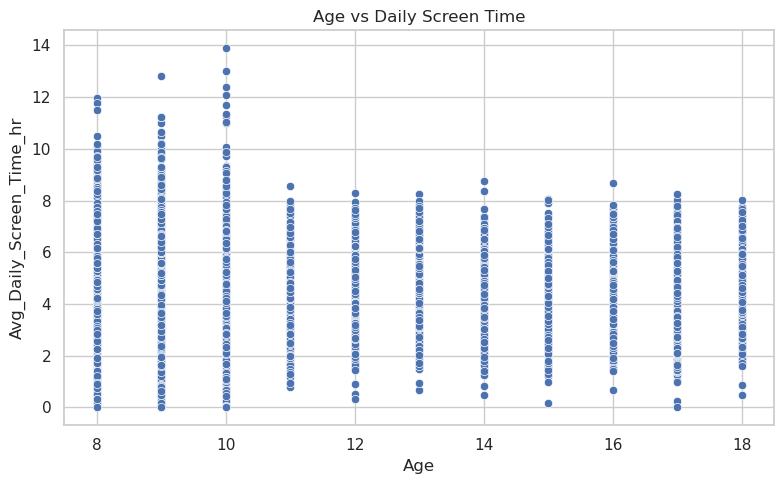

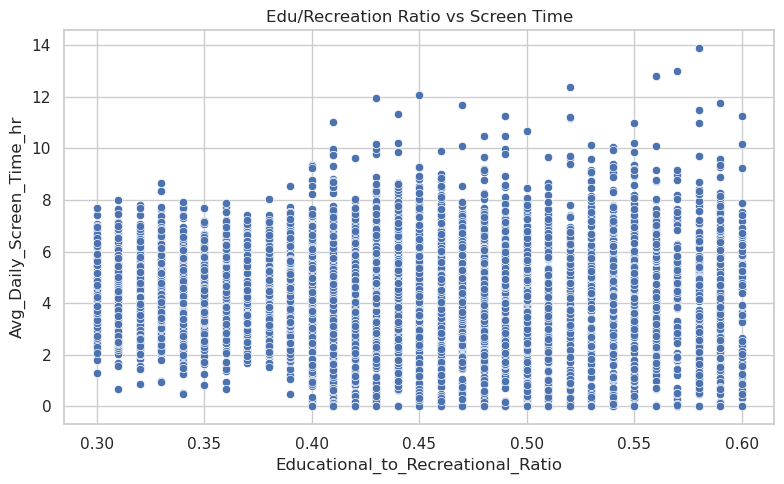

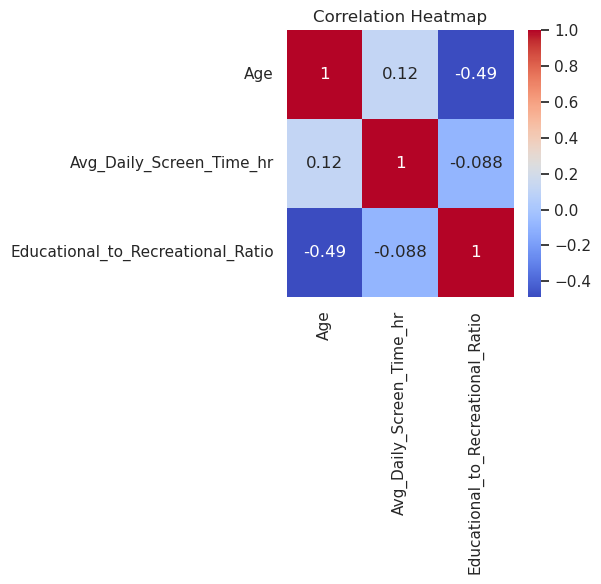

In [67]:
#Age vs Screen Time (Scatter Plot)
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title('Age vs Daily Screen Time')
plt.tight_layout()
plt.show()

#Ratio vs Screen Time (Scatter Plot)
plt.figure(figsize=(8,5))
sns.scatterplot(x='Educational_to_Recreational_Ratio',
                y='Avg_Daily_Screen_Time_hr',
                data=df)
plt.title('Edu/Recreation Ratio vs Screen Time')
plt.tight_layout()
plt.show()

#Correlation Heatmap (All Numeric)
plt.figure(figsize=(6,6))
numeric_cols = df[['Age',
                   'Avg_Daily_Screen_Time_hr',
                   'Educational_to_Recreational_Ratio']]

sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()



CATEGORICAL vs NUMERIC

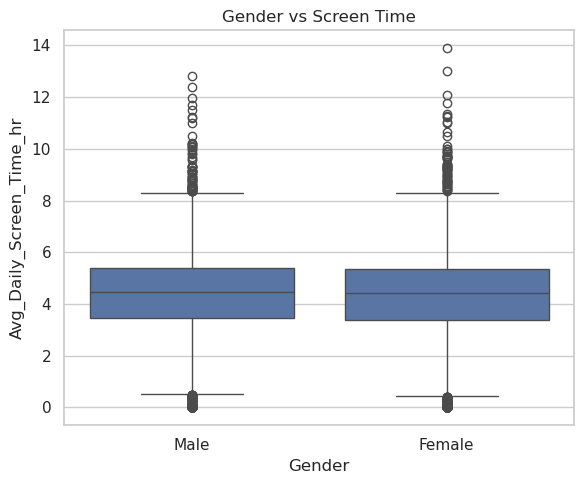

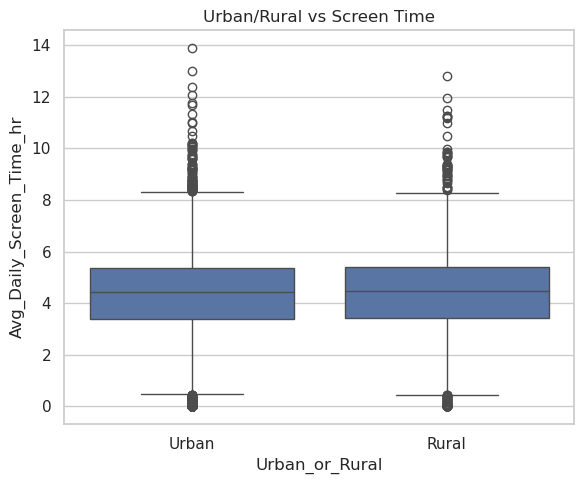

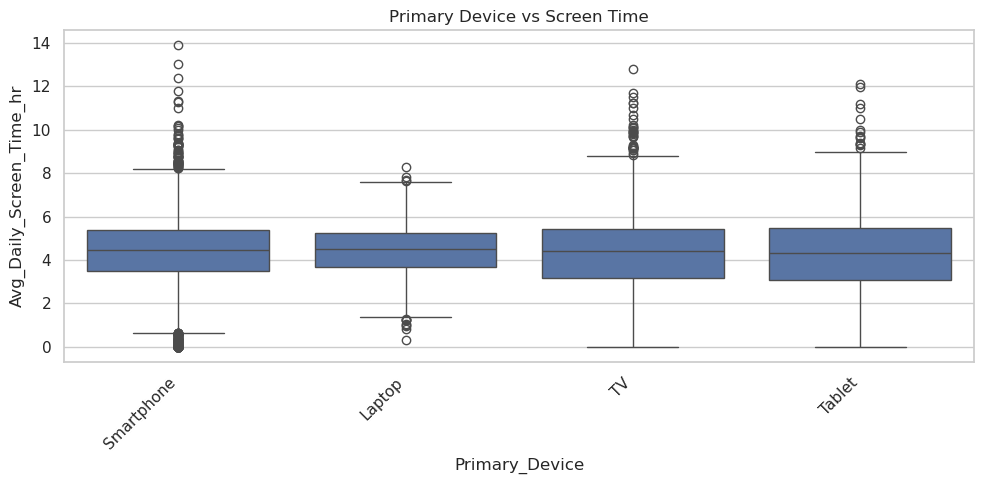

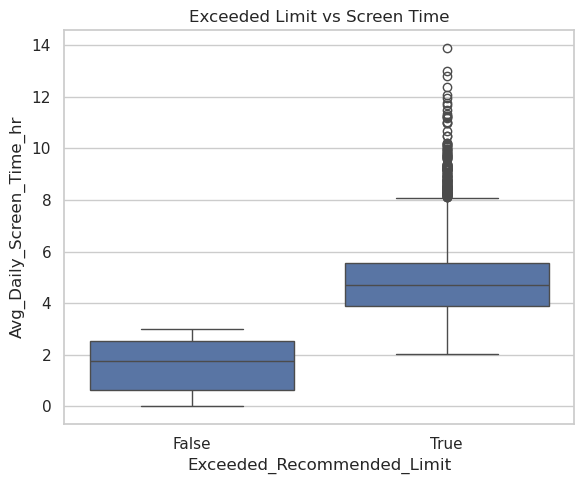

In [68]:
#Gender vs Screen Time (Boxplot)
plt.figure(figsize=(6,5))
sns.boxplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title('Gender vs Screen Time')
plt.tight_layout()
plt.show()

#Urban/Rural vs Screen Time
plt.figure(figsize=(6,5))
sns.boxplot(x='Urban_or_Rural',
            y='Avg_Daily_Screen_Time_hr',
            data=df)
plt.title('Urban/Rural vs Screen Time')
plt.tight_layout()
plt.show()


#Primary Device vs Screen Time
plt.figure(figsize=(10,5))
sns.boxplot(x='Primary_Device',
            y='Avg_Daily_Screen_Time_hr',
            data=df)

plt.xticks(rotation=45, ha='right')
plt.title('Primary Device vs Screen Time')
plt.tight_layout()
plt.show()

#Exceeded Limit vs Screen Time
plt.figure(figsize=(6,5))
sns.boxplot(x='Exceeded_Recommended_Limit',
            y='Avg_Daily_Screen_Time_hr',
            data=df)

plt.title('Exceeded Limit vs Screen Time')
plt.tight_layout()
plt.show()


CATEGORICAL vs CATEGORICAL

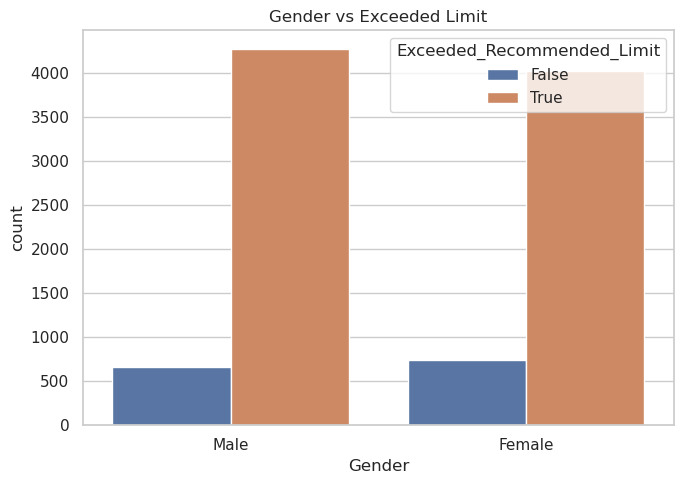

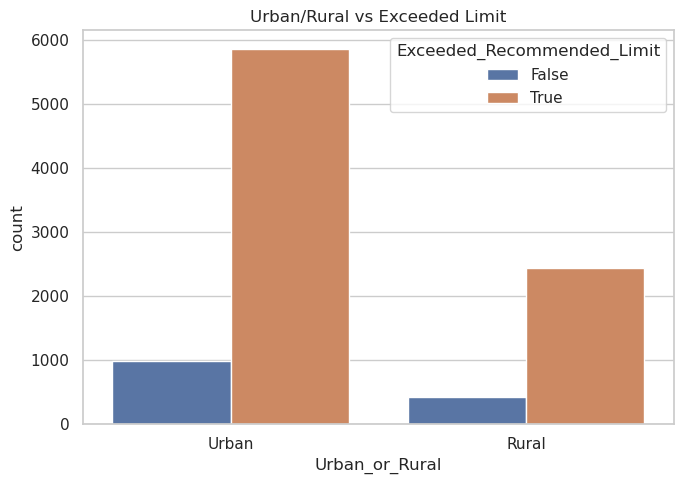

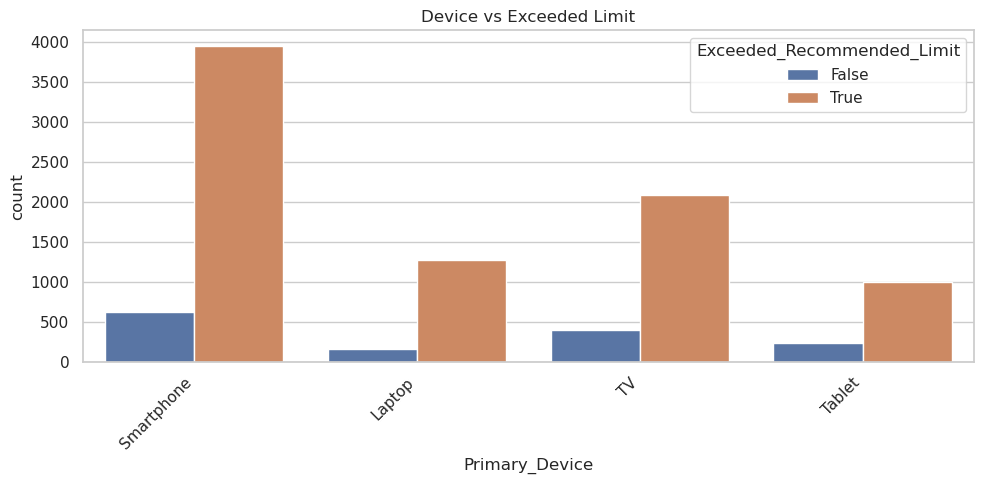

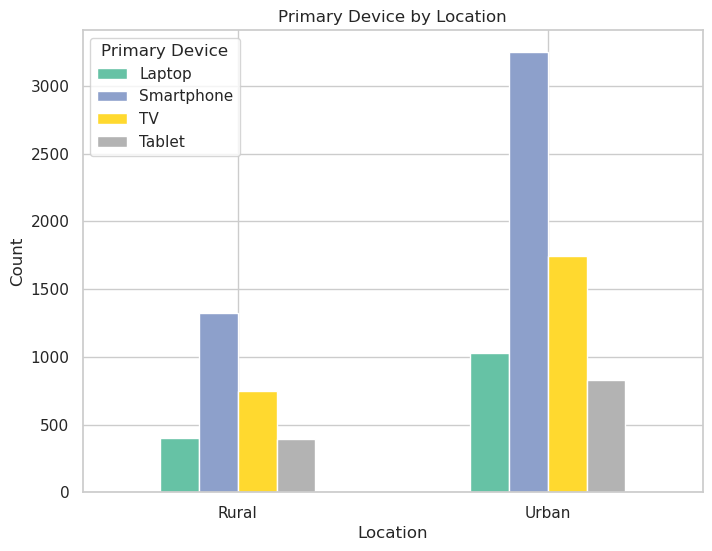

In [70]:
#Gender vs Exceeded Limit (Countplot)
plt.figure(figsize=(7,5))
sns.countplot(x='Gender',
              hue='Exceeded_Recommended_Limit',
              data=df)

plt.title('Gender vs Exceeded Limit')
plt.tight_layout()
plt.show()

#Urban/Rural vs Exceeded Limit
plt.figure(figsize=(7,5))
sns.countplot(x='Urban_or_Rural',
              hue='Exceeded_Recommended_Limit',
              data=df)

plt.title('Urban/Rural vs Exceeded Limit')
plt.tight_layout()
plt.show()

#Device vs Exceeded Limit
plt.figure(figsize=(10,5))
sns.countplot(x='Primary_Device',
              hue='Exceeded_Recommended_Limit',
              data=df)
plt.xticks(rotation=45, ha='right')
plt.title('Device vs Exceeded Limit')
plt.tight_layout()
plt.show()

pd.crosstab(df['Urban_or_Rural'], df['Primary_Device']).plot(
    kind='bar',
    figsize=(8,6),
    rot=0,
    colormap='Set2'
)
plt.title("Primary Device by Location")
plt.xlabel("Location")
plt.ylabel("Count")
plt.legend(title="Primary Device")
plt.show()



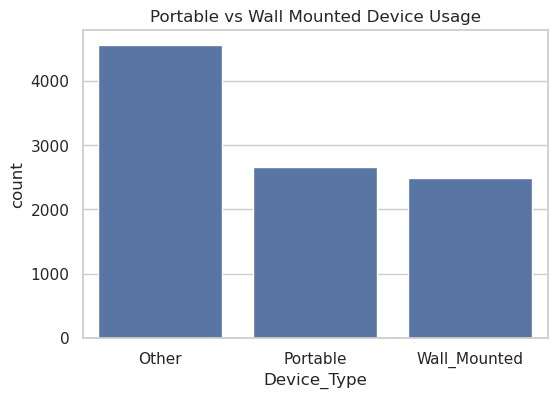

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='Device_Type', data=df)
plt.title('Portable vs Wall Mounted Device Usage')
plt.show()

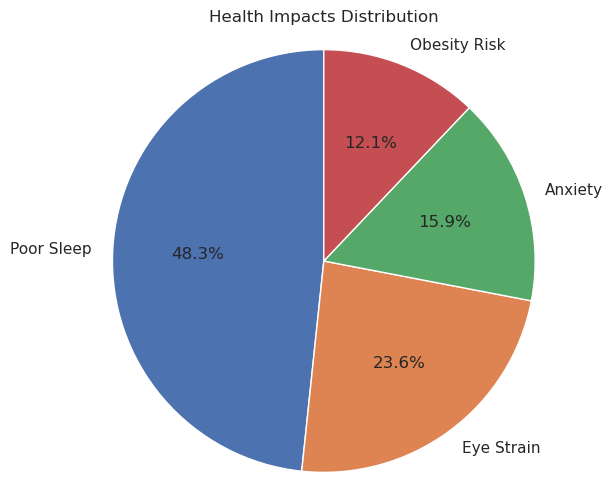

In [73]:
import matplotlib.pyplot as plt
impact_counts = df_exploded['Health_Impact_Category'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(impact_counts,
        labels=impact_counts.index,
        autopct='%1.1f%%',
        startangle=90)
impact_counts = impact_counts.sort_values(ascending=False)
plt.title('Health Impacts Distribution')
plt.axis('equal')   
plt.show()

In [ ]:
Key Insights
